# Ex 3: Grade-specific Models vs. General Model 
* drop_leave = True
* Models : XGBoost, LightGBM

## Setup

First, let's import a few common modules.

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import pandas as pd
import os

# to make this notebook's output stable across runs
import random
seed_val = 42
np.random.seed(seed_val)
random.seed(seed_val)


## Data Loading and Building Train-set & Test-set

### Dataset Builder : Filtering and Labeling

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def build_dataset(df, t_begin, t_end, drop_leave):
    # --- 1. Validation checks ---
    if t_end == 0 and t_begin != 0:
        raise ValueError("When t_end=0, t_begin must be 0.")
    
    # --- 2. Drop entries with invalid current state ---
    # If t_begin is not 0, exclude rows where the student is already in a dropout/specific state
    if t_begin != 0:
        df = df.loc[~df['state_now'].isin([1, 2]), :].copy()

    # --- 3. Handle Right Censoring ---
    # Remove rows that do not have enough future periods to observe up to t_end
    if t_end == 1:
        censored = (df['year'] == 2023) & (df['semester'] == 2)
    elif t_end == 2:
        censored = (df['year'] == 2023)
    elif t_end == 3:
        censored = (df['year'] == 2023) | ((df['year'] == 2022) & (df['semester'] == 2))
    else:
        censored = pd.Series(False, index=df.index)
    
    if t_end != 0:
        df = df.loc[~censored, :].copy()

    # --- 4. Define relevant state columns ---
    # Includes current state and all future states up to t_end
    state_cols = ['state_now'] + [f'state_next_{i}' for i in range(1, t_end + 1)]

    # --- 5. Determine leave status (state == 3) and filtering ---
    # is_always_leave: Student remains in 'leave' state (3) throughout the entire observation period
    is_always_leave = (df[state_cols] == 3).all(axis=1)
    # is_leave: Student is in 'leave' state (3) at the baseline (t=0 or t=1)
    is_leave = df[state_cols[0 if t_end == 0 else 1]].isin([3])

    if drop_leave == False: 
        # Keep students who are 'always on leave' even if they meet the is_leave criteria
        # This treats consistent leave as a non-dropout case (is_drop=0)
        df = df.loc[~is_leave | is_always_leave, :].copy()
    else:
        # Standard filtering: remove anyone who is on leave at the baseline
        df = df.loc[~is_leave].copy()
    
    # --- 6. Determine dropout status (state == 2) ---
    # Define which columns to check for dropout based on t_begin
    relevant_cols = state_cols if t_begin == 0 else state_cols[1:]
    
    # Label as 1 if state 2 (dropout) appears in any relevant columns, else 0
    # Note: 'always_leave' students kept above will naturally get is_drop = 0
    is_drop = df[relevant_cols].isin([2]).any(axis=1)
    df.loc[:, 'is_drop'] = is_drop.astype(int)

    # --- 7. Finalize dataset ---
    df.reset_index(drop=True, inplace=True)
    return df

### Loading Test-set

In [3]:
seed = 42
df = pd.read_csv(f"../datasets/train_tempo_t2.csv")
train_set = build_dataset(df, t_begin=1, t_end=2, drop_leave=True)
train_set.info()

df = pd.read_csv(f"../datasets/test_tempo_t2.csv")
test_set = build_dataset(df, t_begin=1, t_end=2, drop_leave=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15764 entries, 0 to 15763
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index_o            15764 non-null  int64  
 1   year               15764 non-null  int64  
 2   semester           15764 non-null  int64  
 3   grade              15764 non-null  int64  
 4   sex                15764 non-null  object 
 5   gpa_last_seme      15764 non-null  float64
 6   credits_last_seme  15764 non-null  float64
 7   credits_tot        15764 non-null  float64
 8   n_seme             15764 non-null  int64  
 9   years_since        15764 non-null  int64  
 10  sno_hashed         15764 non-null  object 
 11  state_next_1       15764 non-null  float64
 12  state_next_2       13353 non-null  float64
 13  state_next_3       9807 non-null   float64
 14  state_now          15764 non-null  int64  
 15  college            15764 non-null  object 
 16  adm_unit           157

* Sampling from original train-set to make a smaller train-set

In [4]:
#train_set = train_set.sample(frac=0.8, random_state=42).reset_index(drop=True)

In [5]:
X_train = train_set.drop(['is_drop'], axis=1)
y_train = train_set['is_drop'].copy()

X_test = test_set.drop(['is_drop'], axis=1)
y_test = test_set['is_drop'].copy()

## Data Transformation

Label encoding for categorical features

In [6]:
def sex_mapping(sex):
    sex_map = {'M': 0, 'F': 1}
    return sex_map[sex]

def seme_mapping(seme): # semester (Spring/Fall)
    seme_map = {1: 0, 2: 1}
    return seme_map[seme]

def college_mapping(college):
    college_map = {'TH': 0, 'HS': 1, 'BZ': 2, 'HT': 3, 'EG': 4, 'SW': 5, 'AT': 6}
    return college_map[college]

def label_encoding(data):
    data['sex'] = data['sex'].map(sex_mapping)
    data['semester'] = data['semester'].map(seme_mapping)
    data['college'] = data['college'].map(college_mapping)

Pipeline for encoding and scaling

In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

num_attrs = ['grade', 'gpa_last_seme', 'credits_last_seme', 'credits_tot', 'n_seme', 'years_since']
cat_attrs = ['semester', 'sex', 'adm_unit', 'nation', 'in_capa', 'college', 'leave']

full_pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attrs),
    ('cat', OneHotEncoder(), cat_attrs)
])

cat_pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_attrs),
    ('cat', 'passthrough', cat_attrs)
])

# for XGBoost and LightGBM with label encoding
label_encoding(X_train)
X_train = cat_pipeline.fit_transform(X_train) 
X_train = pd.DataFrame(X_train, columns=cat_pipeline.get_feature_names_out()) 


In [8]:
# Typesetting for LGBM
num_cols = ['num__grade', 'num__gpa_last_seme', 'num__credits_last_seme', 'num__credits_tot', 'num__n_seme', 'num__years_since']
            #, 'num__delta_gpa']
cat_cols = list(set(X_train.columns) - set(num_cols))

X_train[num_cols] = X_train[num_cols].astype(float)
X_train[cat_cols] = X_train[cat_cols].astype(int)

In [9]:
label_encoding(X_test)
X_test = cat_pipeline.transform(X_test)
X_test = pd.DataFrame(X_test, columns=cat_pipeline.get_feature_names_out())

# Typesetting
X_test[num_cols] = X_test[num_cols].astype(float)
X_test[cat_cols] = X_test[cat_cols].astype(int)

## Modular Pipeline: Train and Test

In [10]:
import optuna
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (precision_recall_curve, f1_score, average_precision_score, 
                             roc_auc_score, recall_score, precision_score, matthews_corrcoef)

import warnings
warnings.filterwarnings('ignore')

c:\Users\jin\OneDrive\data_sci\college-dropout\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Generalized Objective Function for Optuna

In [11]:
def objective(trial, model_name, X_t, y_t, X_v, y_v):
    pos_weight = (len(y_t) - sum(y_t)) / sum(y_t)
    if model_name == 'xgb':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_estimators': 2000,
            'random_state': 42,
            'use_label_encoder': False,
            'eval_metric': 'aucpr',
            'scale_pos_weight': pos_weight
        }
        model = XGBClassifier(**param)
        model.fit(
            X_t, y_t, 
            eval_set=[(X_v, y_v)], 
            early_stopping_rounds=50, 
            verbose=False
        )
        
    elif model_name == 'lgbm':
        param = {
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 5),
            'num_leaves': trial.suggest_int('num_leaves', 7, 31),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_estimators': 2000,
            'random_state': 42,
            'n_jobs': -1,
            'is_unbalance': True
        }
        model = LGBMClassifier(**param)
        model.fit(
            X_t, y_t, 
            eval_set=[(X_v, y_v)], 
            eval_metric='average_precision',
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
    else:
        raise ValueError("Unsupported model_name. Choose 'xgb' or 'lgbm'.")

    # Use predict_proba for AP calculation
    preds_proba = model.predict_proba(X_v)[:, 1]
    return average_precision_score(y_v, preds_proba)

### TRAIN Fuction


In [12]:
def train_model(model_name, X_train, y_train):
    print(f"\n=======================================================")
    print(f"--- Training Model: {model_name.upper()} ---")
    print(f"=======================================================")

    # [Phase 1] Hyperparameter Tuning
    print("--- [Phase 1] Tuning with Optuna ---")
    X_tune_t, X_tune_v, y_tune_t, y_tune_v = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(
        lambda trial: objective(trial, model_name, X_tune_t, y_tune_t, X_tune_v, y_tune_v), 
        n_trials=30
    )
    best_params = study.best_params
    print(f"Optimal parameters: {best_params}\n")

    # [Phase 2] K-Fold OOF Training
    print("--- [Phase 2] K-Fold OOF Training ---")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_probs = np.zeros(len(X_train))
    trained_models = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        if model_name == 'xgb':
            model = XGBClassifier(**best_params, n_estimators=5000, random_state=42, eval_metric='aucpr')
            model.fit(X_t, y_t, eval_set=[(X_v, y_v)], early_stopping_rounds=50, verbose=False)
            best_iter = model.get_booster().best_iteration
            
        elif model_name == 'lgbm':
            best_params['subsample_freq'] = 1
            model = LGBMClassifier(**best_params, n_estimators=5000, random_state=42, n_jobs=-1)
            model.fit(
                X_t, y_t, eval_set=[(X_v, y_v)], eval_metric='average_precision',
                callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
            )
            best_iter = model.best_iteration_
            
        oof_probs[val_idx] = model.predict_proba(X_v)[:, 1]
        trained_models.append(model)
        print(f"  -> Fold {fold+1} completed (Best Iteration: {best_iter})")

    # [Phase 3] OOF Evaluation & Threshold Tuning
    print("\n--- [Phase 3] OOF Evaluation & Threshold Optimization ---")
    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-5)
    best_thre = thresholds[np.argmax(f1_scores)]
    print(f"Optimal Threshold (from OOF): {best_thre:.4f}\n")

    # Calculate OOF Metrics (for checking train-validation performance)
    ap = average_precision_score(y_train, oof_probs)
    auc = roc_auc_score(y_train, oof_probs)
    
    preds_no = (oof_probs > 0.5).astype(int)
    recall_no = recall_score(y_train, preds_no)
    preci_no = precision_score(y_train, preds_no)
    f1_no = f1_score(y_train, preds_no)
    mcc_no = matthews_corrcoef(y_train, preds_no)
    
    preds_opt = (oof_probs > best_thre).astype(int)
    recall_opt = recall_score(y_train, preds_opt)
    preci_opt = precision_score(y_train, preds_opt)
    f1_opt = f1_score(y_train, preds_opt)
    mcc_opt = matthews_corrcoef(y_train, preds_opt)
    
    oof_res = {
        'ap': ap, 'auc': auc, 
        'recall': recall_no, 'precision': preci_no, 'f1': f1_no, 'mcc': mcc_no, 
        'recall(opt)': recall_opt, 'precision(opt)': preci_opt, 'f1(opt)': f1_opt, 'mcc(opt)': mcc_opt, 
        'threshold': best_thre
    }
    
    return trained_models, best_thre, oof_res

### TEST Function

In [13]:
def test_model(trained_models, best_thre, X_test, y_test):
    print("--- [Phase 4] Final Test Evaluation ---")
    
    # Soft voting ensemble
    test_probs_list = [model.predict_proba(X_test)[:, 1] for model in trained_models]
    ensemble_test_probs = np.mean(test_probs_list, axis=0)
    
    # Calculate Probabilistic Metrics
    ap = average_precision_score(y_test, ensemble_test_probs)
    auc = roc_auc_score(y_test, ensemble_test_probs)
    
    # Predictions at Default Threshold (0.5)
    preds_no = (ensemble_test_probs > 0.5).astype(int)
    recall_no = recall_score(y_test, preds_no)
    preci_no = precision_score(y_test, preds_no)
    f1_no = f1_score(y_test, preds_no)
    mcc_no = matthews_corrcoef(y_test, preds_no)
    
    # Predictions at Optimized Threshold
    preds_opt = (ensemble_test_probs > best_thre).astype(int)
    recall_opt = recall_score(y_test, preds_opt)
    preci_opt = precision_score(y_test, preds_opt)
    f1_opt = f1_score(y_test, preds_opt)
    mcc_opt = matthews_corrcoef(y_test, preds_opt)
    
    test_res = {
        'ap': ap, 'auc': auc, 
        'recall': recall_no, 'precision': preci_no, 'f1': f1_no, 'mcc': mcc_no, 
        'recall(opt)': recall_opt, 'precision(opt)': preci_opt, 'f1(opt)': f1_opt, 'mcc(opt)': mcc_opt, 
        'threshold': best_thre
    }
    
    print("Test Evaluation Completed.\n")
    return test_res

## Execute Experiments and Collect Results

In [14]:
import pandas as pd
import numpy as np

# A list to store all experiment results
experiment_results = []

algorithms = ['xgb', 'lgbm']
grades_raw = [1, 2, 3, 4]

# Define the clusters
clusters = {
    'Lower': [1, 2],
    'Upper': [3, 4]
}

# ==========================================
# [Crucial Step] Handle Standard-Scaled 'grade' Feature
# ==========================================
scaled_grades = sorted(X_train['num__grade'].unique())
grade_mapping = {g: scaled_g for g, scaled_g in zip(grades_raw, scaled_grades)}

print("--- Scaled Grade Mapping ---")
for g, s_val in grade_mapping.items():
    print(f"Grade {g} is represented as: {s_val:.4f} in the dataset")
print("----------------------------\n")

def get_cluster_mask(df, target_grades, mapping):
    mask = np.zeros(len(df), dtype=bool)
    for g in target_grades:
        mask |= np.isclose(df['num__grade'], mapping[g])
    return mask

for algo in algorithms:
    print(f"--- Starting unified experiments for Algorithm: {algo.upper()} ---")
    
    # ------------------------------------------
    # [Strategy 1] Grade-Specific Models
    # (Train on Grade X, Evaluate on Grade X)
    # ------------------------------------------
    for grade in grades_raw:
        scaled_target_val = grade_mapping[grade]
        mask = np.isclose(X_train['num__grade'], scaled_target_val)
        test_mask = np.isclose(X_test['num__grade'], scaled_target_val)
        
        # Drop 'num__grade' as it's constant for a single grade
        X_train_g = X_train[mask].drop(columns=['num__grade'])
        y_train_g = y_train[mask].copy()
        X_test_g = X_test[test_mask].drop(columns=['num__grade'])
        y_test_g = y_test[test_mask].copy()
        
        model_specific, thres_s, _ = train_model(algo, X_train_g, y_train_g)
        metrics_specific = test_model(model_specific, thres_s, X_test_g, y_test_g)
        
        res_specific = {'Algorithm': algo.upper(), 'Model_Type': 'Grade-Specific', 'Evaluated_On': f'Grade {grade}'}
        res_specific.update(metrics_specific) 
        experiment_results.append(res_specific)

    # ------------------------------------------
    # [Strategy 2] Cluster-Specific Models
    # (Train on Cluster, Evaluate on Individual Grades)
    # ------------------------------------------
    for cluster_name, target_grades in clusters.items():
        train_mask = get_cluster_mask(X_train, target_grades, grade_mapping)
        X_train_c = X_train[train_mask].copy()
        y_train_c = y_train[train_mask].copy()
        
        model_cluster, thres_c, _ = train_model(algo, X_train_c, y_train_c)
        
        for grade in target_grades:
            scaled_target_val = grade_mapping[grade]
            test_mask = np.isclose(X_test['num__grade'], scaled_target_val)
            
            X_test_g = X_test[test_mask].copy()
            y_test_g = y_test[test_mask].copy()
            
            metrics_cluster = test_model(model_cluster, thres_c, X_test_g, y_test_g)
            
            res_cluster = {'Algorithm': algo.upper(), 'Model_Type': 'Cluster-Specific', 'Evaluated_On': f'Grade {grade}'}
            res_cluster.update(metrics_cluster) 
            experiment_results.append(res_cluster)

    # ------------------------------------------
    # [Strategy 3] General Model
    # (Train on All, Evaluate on Individual Grades)
    # ------------------------------------------
    model_general, thres_g, _ = train_model(algo, X_train, y_train)
    
    for grade in grades_raw:
        scaled_target_val = grade_mapping[grade]
        test_mask = np.isclose(X_test['num__grade'], scaled_target_val)
        
        X_test_g = X_test[test_mask].copy()
        y_test_g = y_test[test_mask].copy()
        
        metrics_general = test_model(model_general, thres_g, X_test_g, y_test_g)
        
        res_general = {'Algorithm': algo.upper(), 'Model_Type': 'General (Cross-Eval)', 'Evaluated_On': f'Grade {grade}'}
        res_general.update(metrics_general)
        experiment_results.append(res_general)


--- Scaled Grade Mapping ---
Grade 1 is represented as: -1.7141 in the dataset
Grade 2 is represented as: -0.7449 in the dataset
Grade 3 is represented as: 0.2244 in the dataset
Grade 4 is represented as: 1.1937 in the dataset
----------------------------

--- Starting unified experiments for Algorithm: XGB ---

--- Training Model: XGB ---
--- [Phase 1] Tuning with Optuna ---
Optimal parameters: {'learning_rate': 0.06054365855469246, 'max_depth': 4, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978}

--- [Phase 2] K-Fold OOF Training ---
  -> Fold 1 completed (Best Iteration: 78)
  -> Fold 2 completed (Best Iteration: 37)
  -> Fold 3 completed (Best Iteration: 90)
  -> Fold 4 completed (Best Iteration: 46)
  -> Fold 5 completed (Best Iteration: 15)

--- [Phase 3] OOF Evaluation & Threshold Optimization ---
Optimal Threshold (from OOF): 0.2757

--- [Phase 4] Final Test Evaluation ---
Test Evaluation Completed.


--- Training Model: XGB ---
--- [Phase 1] Tuning with 

In [15]:

# ==========================================
# [Result Output]
# ==========================================
results_df = pd.DataFrame(experiment_results)

# Clean sorting for the unified table
eval_order = ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
model_order = ['Grade-Specific', 'Cluster-Specific', 'General (Cross-Eval)']

results_df['Evaluated_On'] = pd.Categorical(results_df['Evaluated_On'], categories=eval_order, ordered=True)
results_df['Model_Type'] = pd.Categorical(results_df['Model_Type'], categories=model_order, ordered=True)

results_df = results_df.sort_values(by=['Evaluated_On', 'Algorithm', 'Model_Type']).reset_index(drop=True)

print("\n=== Unified Final Experiment Results ===")
print(results_df.to_markdown(index=False))


=== Unified Final Experiment Results ===
| Algorithm   | Model_Type           | Evaluated_On   |       ap |      auc |    recall |   precision |        f1 |      mcc |   recall(opt) |   precision(opt) |   f1(opt) |   mcc(opt) |   threshold |
|:------------|:---------------------|:---------------|---------:|---------:|----------:|------------:|----------:|---------:|--------------:|-----------------:|----------:|-----------:|------------:|
| LGBM        | Grade-Specific       | Grade 1        | 0.636376 | 0.88936  | 0.265306  |    0.866667 | 0.40625   | 0.46266  |      0.663265 |         0.637255 |  0.65     |   0.62421  |   0.159991  |
| LGBM        | Cluster-Specific     | Grade 1        | 0.621015 | 0.892615 | 0.0714286 |    0.777778 | 0.130841  | 0.223571 |      0.683673 |         0.54918  |  0.609091 |   0.581448 |   0.100574  |
| LGBM        | General (Cross-Eval) | Grade 1        | 0.616483 | 0.901581 | 0.357143  |    0.777778 | 0.48951   | 0.506288 |      0.663265 |         0.6

--- Displaying Unified Comparison for f1(opt) ---


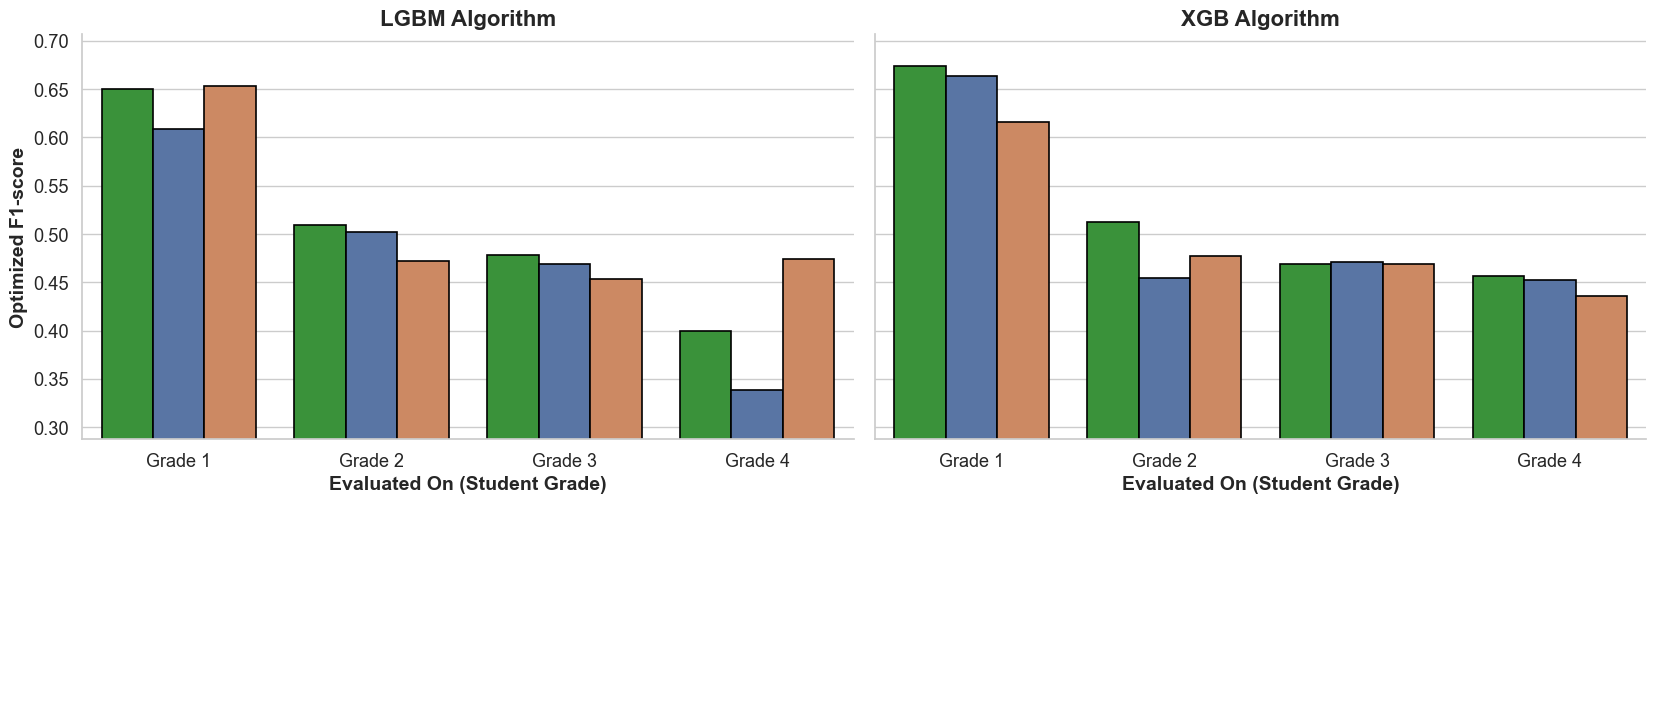

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# [Visualization Setup]
# ==========================================
metric_to_plot = 'f1(opt)'

sns.set_theme(style="whitegrid", font_scale=1.2) 
plt.rcParams['font.family'] = 'sans-serif' 

# Copy dataframe to avoid warnings
df_plot = results_df.copy()

# ==========================================
# [Generate Grouped Bar Chart]
# ==========================================
# Colors: Green (Grade), Blue (Cluster), Orange (General)
colors = ["#2ca02c", "#4C72B0", "#dd8452"] 
sns.set_palette(sns.color_palette(colors))

# Create the faceted bar chart
g = sns.catplot(
    data=df_plot,
    x='Evaluated_On',      # X-axis: Grades 1 to 4
    y=metric_to_plot,      # Y-axis: Performance metric
    hue='Model_Type',      # Compare the 3 modeling strategies
    col='Algorithm',       # Split by LGBM and XGB
    kind='bar',            
    height=6,              
    aspect=1.4,            # Made slightly wider to fit 3 bars per grade nicely
    edgecolor="black",     
    linewidth=1.2          
)

# ==========================================
# [Chart Customization & Formatting]
# ==========================================
g.set_titles("{col_name} Algorithm", size=16, weight='bold') 
g.set_axis_labels("Evaluated On (Student Grade)", "Optimized F1-score", size=14, weight='bold')

g.set_xticklabels(size=13)

# Fine-tune Y-axis to highlight performance gaps clearly
min_val = df_plot[metric_to_plot].min()
max_val = df_plot[metric_to_plot].max()
# If minimum is 0 (e.g., failed Grade 3 Specific), handle it safely
lower_bound = 0 if min_val == 0 else min_val * 0.85
g.set(ylim=(lower_bound, max_val * 1.05)) 

# Adjust legend
g._legend.set_title("Modeling Strategy")
plt.setp(g._legend.get_title(), fontsize='13', weight='bold') 
g._legend.set_bbox_to_anchor((0.5, -0.1)) # Place below the charts

plt.subplots_adjust(bottom=0.25) 

# plt.savefig('fig_unified_model_comparison.png', dpi=300, bbox_inches='tight')

print(f"--- Displaying Unified Comparison for {metric_to_plot} ---")
plt.show()

In [17]:
import pandas as pd
import numpy as np

# ==========================================
# [Data Distribution Summary]
# ==========================================
# 1. Recover the scaled grade mapping
grades_raw = [1, 2, 3, 4]
scaled_grades = sorted(X_train['num__grade'].unique())
grade_mapping = {g: scaled_g for g, scaled_g in zip(grades_raw, scaled_grades)}

# List to store the distribution statistics
distribution_stats = []

for grade in grades_raw:
    scaled_target_val = grade_mapping[grade]
    
    # 2. Create boolean masks for each grade safely
    train_mask = np.isclose(X_train['num__grade'], scaled_target_val)
    test_mask = np.isclose(X_test['num__grade'], scaled_target_val)
    
    # 3. Filter the target variables (y_train, y_test)
    y_train_g = y_train[train_mask]
    y_test_g = y_test[test_mask]
    
    # 4. Calculate total samples and positive samples (assuming positive class is 1)
    train_total = len(y_train_g)
    train_pos = y_train_g.sum()  # Sum of 1s
    
    test_total = len(y_test_g)
    test_pos = y_test_g.sum()    # Sum of 1s
    
    # 5. Store the results
    distribution_stats.append({
        'Grade': f'Grade {grade}',
        'Train_Total': train_total,
        'Train_Positive': int(train_pos),
        'Train_Pos_Ratio(%)': round((train_pos / train_total) * 100, 2) if train_total > 0 else 0,
        'Test_Total': test_total,
        'Test_Positive': int(test_pos),
        'Test_Pos_Ratio(%)': round((test_pos / test_total) * 100, 2) if test_total > 0 else 0
    })

# ==========================================
# [Result Output]
# ==========================================
dist_df = pd.DataFrame(distribution_stats)

print("\n=== Dataset Distribution by Grade ===")
print(dist_df.to_markdown(index=False))


=== Dataset Distribution by Grade ===
| Grade   |   Train_Total |   Train_Positive |   Train_Pos_Ratio(%) |   Test_Total |   Test_Positive |   Test_Pos_Ratio(%) |
|:--------|--------------:|-----------------:|---------------------:|-------------:|----------------:|--------------------:|
| Grade 1 |          1984 |              127 |                 6.4  |         1449 |              98 |                6.76 |
| Grade 2 |          4615 |              360 |                 7.8  |         2460 |             229 |                9.31 |
| Grade 3 |          4302 |              190 |                 4.42 |         2287 |             144 |                6.3  |
| Grade 4 |          4793 |               95 |                 1.98 |         2518 |              62 |                2.46 |
